In [ ]:
#Algorithm outline and testing

In [3]:
# === PART 1: DETECT & LOCALIZE FLIES PER FRAME ===
""" goal is to record latency of frame substraction, ensure that program can keep track of multiple flies in each frame """

#imports
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

In [5]:
#constants
VIDEO_PATH = "LUCID_TRI032S-M_251700592__20251114112116359_video3.avi" #path to AVI file
DOWNSCALE = 1.0 #<1.0 to downscale frames for speed
THRESH_VAL = 25 # frame subtraction threshold
MIN_AREA = 5 # minimum blob area (pixels)
MAX_AREA = 500 # max blob area (pixels)
MAX_MISSED = 10 # allows tracks to survive 10 frames without a detection
MAX_TRACK_DIST = 50 # max distance for track association (pixels)
HISTORY = 50 # frame to keep for plotting

# ROI Configuration
# define ROI as fractions of frame dimensions
ROI_X_MIN = 0.5
ROI_Y_MIN = 0.0

# static object detection
STATIC_THRESH = 120 #grayscale threshold for dark objects 
BACKGROUND_ALPHA = 0.005 # running background update rate

In [7]:
#tracking class
class Track: 
    def __init__(self, track_id, centroid): 
        self.id = track_id
        self.centroids = deque(maxlen=HISTORY)
        self.centroids.append(centroid)
        #self.last_seen = 0 # frame idx when last seen
        self.missed = 0 # num of consecutive frames w/o detection

    @property
    def last_position(self): 
        return self.centroids[-1] # returns last position stored in centroid

In [17]:
# utility functions
def preprocess_and_crop(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray =cv2.equalizeHist(gray)

    h, w = gray.shape 

    # Define ROI fractions (example: right half)
    x0 = int(ROI_X_MIN * w)
    y0 = int(ROI_Y_MIN * h)
    x1 = w
    y1 = h

    roi = gray[y0:y1, x0:x1]

    # force consistent minimum size
    if roi.shape[0] < 8 or roi.shape[1] < 8:
        raise ValueError(f"ROI too small: {roi.shape} from frame {gray.shape}")
    
    #if DOWNSCALE != 1.0:
     #   gray = cv2.resize(
      #      gray,
       #     None,
        #    fx=DOWNSCALE,
         #   fy=DOWNSCALE,
          #  interpolation=cv2.INTER_AREA,
        #)

    return roi, (x0, y0)

def detect_static_objects(curr_gray, bg_model, tracks): 
    # detect small dark objects against light background
    diff = cv2.absdiff(curr_gray, bg_model)
    # ignore areas with tracked flies
    mask = np.ones_like(curr_gray, dtype=np.uint8)*255
    for t in tracks:
        x, y = t.last_position
        cv2.circle(mask, (x,y), 6, 0, -1)

    diff[mask==0]=0
    
    _, thresh = cv2.threshold(diff, STATIC_THRESH, 255, cv2.THRESH_BINARY_INV)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    detections = []
    for c in contours:
        area = cv2.contourArea(c)
        if MIN_AREA <= area <= MAX_AREA:
            M = cv2.moments(c)
            if M['m00'] != 0:
                cx = int(M['m10']/M['m00'])
                cy = int(M['m01']/M['m00'])
                detections.append((cx, cy))
    return detections
    
    #thresh = cv2.medianBlur(mask,5)
    #fg = cv2.bitwise_and(mask, bg_model)
    #return fg

def detect_moving_objects(prev_gray, curr_gray): 
    diff = cv2.absdiff(curr_gray, prev_gray)
    diff = cv2.GaussianBlur(diff, (5,5), 0)
    _, thresh = cv2.threshold(diff, THRESH_VAL, 255, cv2.THRESH_BINARY)
    #thresh = cv2.medianBlur(thresh, 5)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    detections = [] 
    for c in contours: 
        area = cv2.contourArea(c)
        if MIN_AREA <= area <= MAX_AREA: # looking for objects within specifed range size TODO figure out how to determine this 
            M = cv2.moments(c)
            if M['m00'] != 0: 
                cx = int(M['m10']/ M['m00'])
                cy = int(M['m01']/ M['m00'])
                detections.append((cx, cy))
    return detections, thresh

def associate_detections_to_tracking(detections, tracks, next_id): 
    assigned = set() 
    for track in tracks: 
        min_dist = float('inf')
        best_det = None
        for d in detections: 
            if d in assigned: 
                continue
            dist = np.linalg.norm(np.array(track.last_position) - np.array(d))
            if dist < min_dist and dist < MAX_TRACK_DIST: 
                min_dist = dist
                best_det = d
        if best_det is not None: 
            track.centroids.append(best_det)
            track.missed = 0 # reset missed count
            assigned.add(best_det)
        else: 
            track.missed += 1 #increment if missed if not matched

    # create new tracks for unmatched detections
    for d in detections: 
        if d not in assigned: 
            tracks.append(Track(next_id, d))
            next_id += 1

    # remove tracks that have been missed too long
    tracks = [t for t in tracks if t.missed <= MAX_MISSED]
    
    return tracks, next_id

def merge_detections(move_dets, static_dets, merge_radius=5):
    all_dets = move_dets + static_dets
    final = []
    for d in all_dets:
        if all(np.linalg.norm(np.array(d)-np.array(f)) > merge_radius for f in final):
            final.append(d)
    return final

    

In [23]:
# MAIN PROCESSING LOOP
capture = cv2.VideoCapture(VIDEO_PATH)
assert capture.isOpened(), "Could not open video file"

ret, frame = capture.read()
if not ret: 
    raise RuntimeError("Failed to read first frame")
    
prev_gray, roi_offset = preprocess_and_crop(frame)

#initialize background model for static detection
bg_model = prev_gray.copy() #np.ones_like(prev_gray, dtype=np.uint8) * 255

# instantiate empty arrays for tracking and latency calculations
tracks = [] #store tracking in array
next_track_id = 0 
#explicit multi-target capacity metrics
latencies, det_counts, track_counts, frames, thresh_frames = [], [], [], [], []
   
    #frames = []
    #thresh_frames = []

frame_idx = 0

#begin loop, occurs over duration of video
while True: 
    ret, frame = capture.read()
    if not ret: 
        break

    start = time.perf_counter() #records detection speed

    curr_gray, _ = preprocess_and_crop(frame)

    # moving & static object detection
    move_dets, thresh = detect_moving_objects(prev_gray, curr_gray)
    static_dets = detect_static_objects(curr_gray, bg_model, tracks)
    detections = merge_detections(move_dets, static_dets)

    tracks, next_track_id =associate_detections_to_tracking(detections, tracks, next_track_id) 

    #update background model slowly outside tracked flies
    mask = np.ones_like(curr_gray, dtype=np.uint8)*255
    for t in tracks: 
        x, y = t.last_position
        cv2.circle(mask, (x,y), 6, 0, -1) # radius = small area around fly

    # update background only outside masked regions
    #bg_model = cv2.addWeighted(bg_model, 1 - BACKGROUND_ALPHA, curr_gray, BACKGROUND_ALPHA, 0)#(detections, tracks, next_track_id)
    #bg_model[mask == 0] = bg_model[mask ==0] # keep old values where flies are
    #bg_model[mask != 0] = cv2.addWeighted(bg_model[mask !=0], 1 - BACKGROUND_ALPHA, curr_gray[mask != 0], BACKGROUND_ALPHA, 0)

    # Compute weighted update for entire frame
    updated_bg = (1 - BACKGROUND_ALPHA) * bg_model + BACKGROUND_ALPHA * curr_gray
    # Only apply update where mask != 0
    bg_model[mask != 0] = updated_bg[mask != 0].astype(np.uint8)

    # append metrics
    latencies.append((time.perf_counter() - start) * 1000.0) 
    det_counts.append(len(detections))
    track_counts.append(len(tracks))

    #visualization frame
    visual = cv2.cvtColor(curr_gray, cv2.COLOR_GRAY2BGR)
    # draw ROI boundary 
    cv2.rectangle(visual, (0,0), (visual.shape[1]-1, visual.shape[0]-1), (255,255,0),1)
    
    for t in tracks: 
        for i in range(1, len(t.centroids)): 
            cv2.line(visual, t.centroids[i-1], t.centroids[i], (0,255,0), 1)
        cv2.circle(visual, t.last_position, 3, (0,0,255), -1)
        cv2.putText(visual, f"ID {t.id}", (t.last_position[0]+5, t.last_position[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,0,0), 1)

    if frame_idx % 10 == 0: 
        frames.append(visual.copy())
        thresh_frames.append(thresh.copy())

    prev_gray = curr_gray
    frame_idx += 1

capture.release()
print ("Done processing.")
        

KeyboardInterrupt: 

Processed 1555 frames
Average per-frame latency: 111.99 ms
Max per-frame latency: 1150.15 ms
Estimated FPS capability: 8.9 FPS


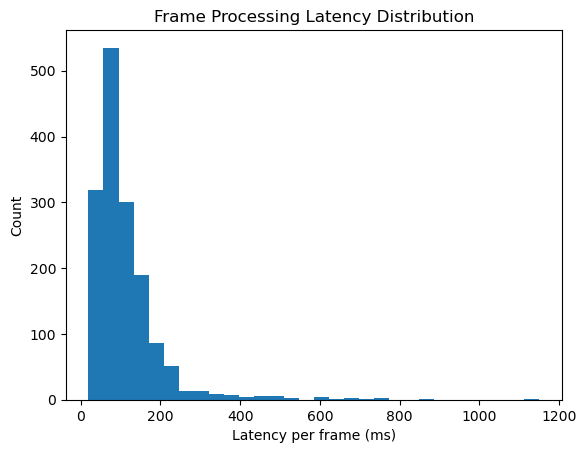

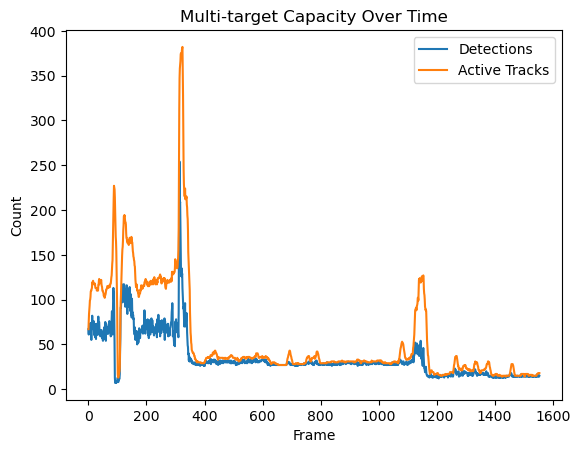

In [163]:
# === RESULTS AND DIAGNOSTICS ===

# latency metrics
print(f"Processed {frame_idx} frames")
print(f"Average per-frame latency: {np.mean(latencies):.2f} ms")
print(f"Max per-frame latency: {np.max(latencies):.2f} ms")
print(f"Estimated FPS capability: {1000.0 / np.mean(latencies):.1f} FPS")

# plot latency distribution 
plt.figure()
plt.hist(latencies, bins=30)
plt.xlabel("Latency per frame (ms)")
plt.ylabel("Count")
plt.title("Frame Processing Latency Distribution")
plt.show()

#plot detection metrics to quantitatively show scaling behavior
plt.figure()
plt.plot(det_counts, label="Detections")
plt.plot(track_counts, label="Active Tracks")
plt.legend()
plt.title("Multi-target Capacity Over Time")
plt.xlabel("Frame")
plt.ylabel("Count")
plt.show()

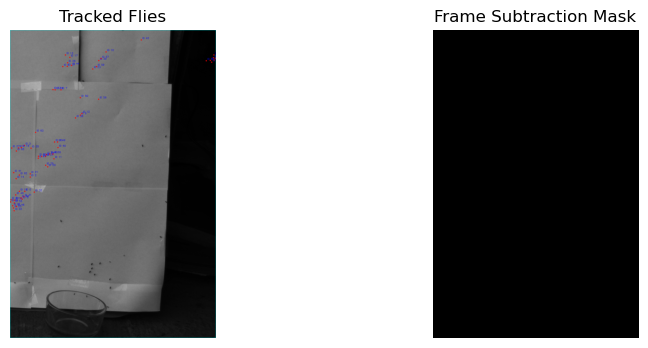

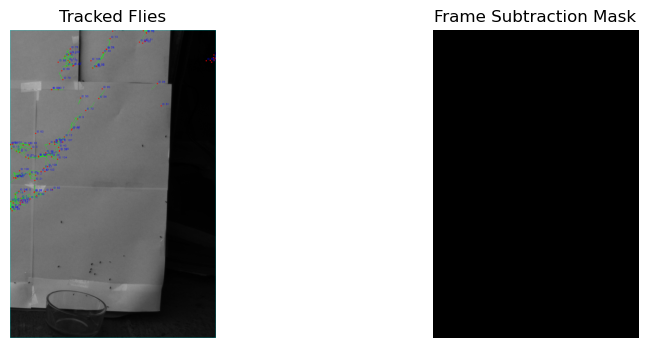

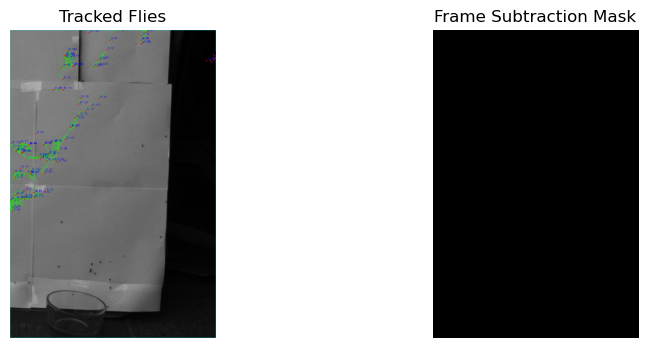

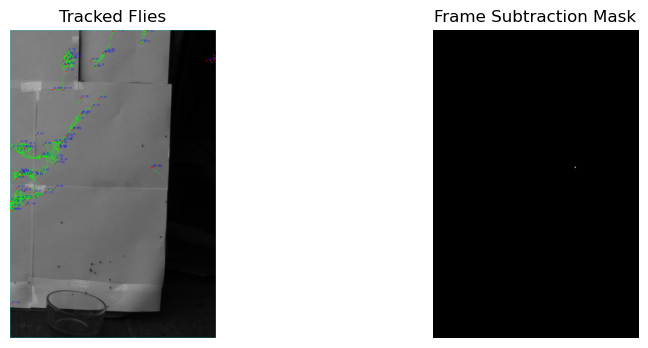

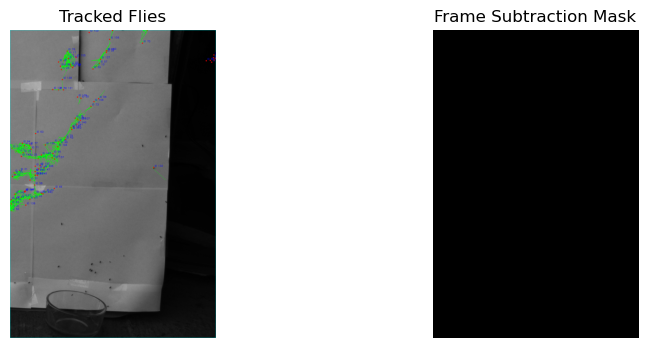

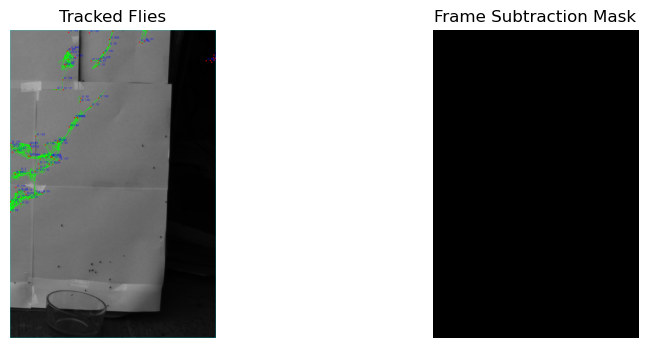

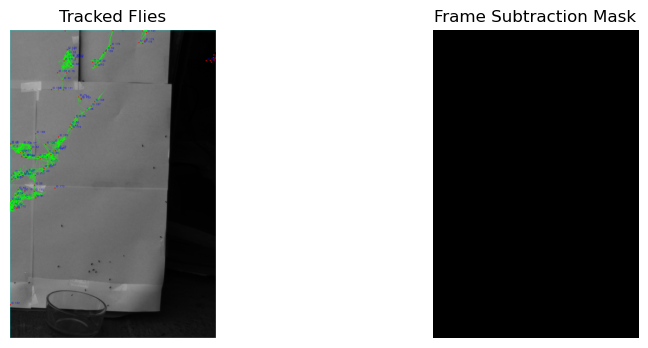

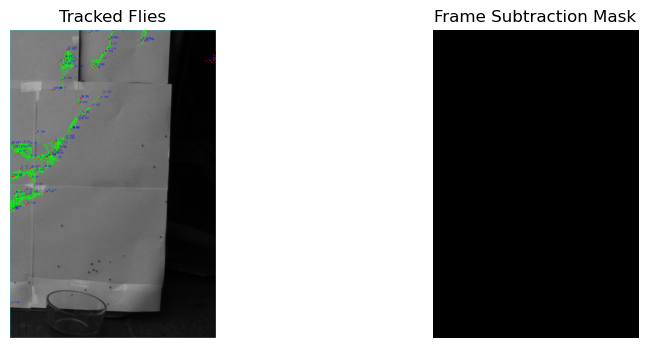

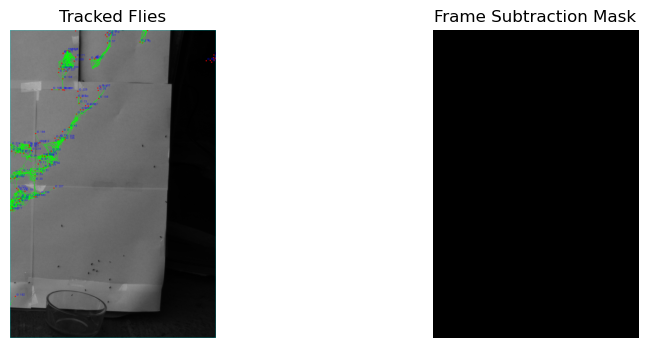

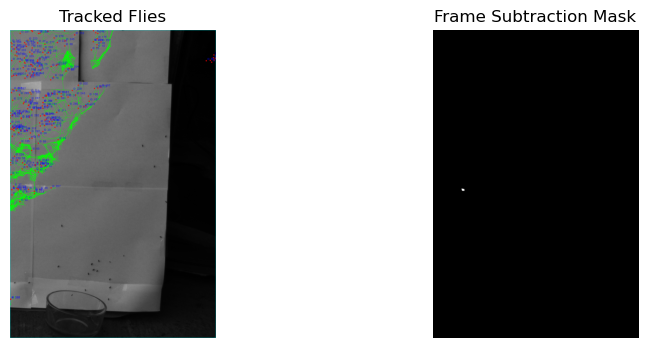

In [165]:
# example frames
num_show = min(10, len(frames))
for i in range(num_show):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(frames[i][..., ::-1])
    plt.title("Tracked Flies")
    plt.axis("off")
    
    
    plt.subplot(1,2,2)
    plt.imshow(thresh_frames[i], cmap='gray')
    plt.title("Frame Subtraction Mask")
    plt.axis("off")
    plt.show()